# SI 313 WN26: Surveys Module Assignment
### Part B: Survey Data Analysis
##### Nick Pisarczyk - 03/25/26<br>uniqname: npisar<br> 
---

# Introduction

Choose ONE research question to investigate:

- Trust in institutions: What predicts trust in government institutions (Congress, presidency, media, science)? How do political affiliation, education, and demographic factors relate to institutional trust?
- Information sources and beliefs: How do different news sources (traditional media, social media, partisan outlets) relate to political knowledge, beliefs about factual matters, or policy preferences?
- Identity and political attitudes: How do different social identities (race, gender, education, religion, region) relate to political preferences? Are there interaction effects between identities?

### <b>RESEARCH QUESTION: - Information sources and beliefs: How do different news sources (traditional media, social media, partisan outlets) relate to political knowledge, beliefs about factual matters, or policy preferences?</b> And I focused on the "political knowledge" aspect of the question ##

I'm interested in this research question because I feel like I've been experiencing the differences in forms of media a lot in my life recently. I've started listening to more podcasts and music instead of watching as much video, and I've noticed a difference in how I consume media and function during my day. I'm interested to see if differences in media sources can have bigger effects, like on how we learn, what knowledge we gain, etc., which is especially important to understand when it comes to politics. With so much political content around nowadays, what's the source I would get the most benefit from using, where I would actually learn the most and be the most informed?

---

# Data Loading and Exploration
- Load ANES data
- Examine variables of interest
- Check missing data patterns
- Create necessary derived variables

In [1]:
# libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import jinja2

import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

In [2]:
# Load the 2020 ANES Time Series data
# df = pd.read_csv("/Users/libbyh/Documents/git/si313_instructors/answer_keys/data/38034-0001-Data.tsv", sep='\t')
df = pd.read_stata("../data/surveys_module_data/38034-0001-Data.dta", convert_categoricals=False)

# news/media sources
# rename variables with friendly names
df = df.rename(columns={
    "V201629A": "tv_used",                   # data about what media sources people heard anything about the presidential campaign from 
    "V201629B": "newspaper_used",            # covers traditional source use of radio/newspaper
    "V201629C": "internet_used",
    "V201629D": "radio_used",

    "V200010A": "weight_full_pre",          # full-sample pre-election weight
})

# political knowledge
# rename variables with friendly names
df = df.rename(columns={
    "V201644": "senator_term",
    "V201645": "least_fed_spending",
    "V201646": "house_majority",
    "V201647": "senate_majority",
})

facts = ["senator_term", "least_fed_spending", "house_majority", "senate_majority"]
media_sources = ["tv_used", "newspaper_used", "internet_used", "radio_used"]
weights = ["weight_full_pre"]

combined_vars = facts+media_sources
vars_and_weights = combined_vars+weights

model_df = df[vars_and_weights].copy()

print(f"head of new dataset")
print(model_df.head())

head of new dataset
   senator_term  least_fed_spending  house_majority  senate_majority  tv_used  \
0             6                   3               1                2        1   
1             2                   4               2                1        1   
2             6                   1               1                2        1   
3             4                   1               2                1        1   
4             6                   1               1                2        1   

   newspaper_used  internet_used  radio_used  weight_full_pre  
0               0              1           1         0.827932  
1               0              1           0         1.087641  
2               1              1           1         0.671765  
3               0              0           0         0.491910  
4               0              1           1         1.189965  


In [3]:
"""
 Recode factual knowledge questions to get binary right or wrong values
    - correct answers are 1
    - incorrect answers are 0
    - all others are NaN
"""

model_df_recoded = model_df.copy()
fact_cols = {'senator_term':6, 'least_fed_spending':1, 'house_majority':1, 'senate_majority':2}
media_cols = media_sources.copy()

# helper functions for recodinng factual questions
def recode_factual_questions(column_name, correct_val):
    conditions = [
            df[column_name] == correct_val,
            df[column_name] > 0,
            df[column_name] < 0,
        ]
    choices = [
        1,
        0,
        np.nan,
    ]

    model_df_recoded[f"{column_name}"] = np.select(conditions, choices, default=model_df_recoded[column_name])
    # print(f"model_df column: {model_df[column_name]}")
    print(f"{column_name} unique vals: {model_df_recoded[column_name].unique()}")

def compare_column_values_factual(column_name, correct_val):
    print(f"ORIGINAL VARS: Column {column_name}:\nCorrect Value = {correct_val}\n{model_df[column_name].value_counts(dropna=False)}\n")
    print(f"RECODED VARS: Column {column_name}:\nCorrect Value = 1.0\n{model_df_recoded[column_name].value_counts(dropna=False)}\n{'='*50}\n\n\n\n")

def compare_frequencies_factual(column_name, correct_val):
    # need the correct answer, any NaNs, any incorrect
    # for first, need 6, any > 0 and not 6, any negative
    n_correct_before = (model_df[column_name] == correct_val).sum()
    n_incorrect_before = ((model_df[column_name] > 0) & ((model_df)[column_name] != correct_val)).sum()
    n_negative_before = (model_df[column_name] < 0).sum()

    # compare now to recoded
    n_correct_after = (model_df_recoded[column_name] == 1.0).sum()
    n_incorrect_after = (model_df_recoded[column_name] == 0.0).sum()
    n_negative_after = model_df_recoded[column_name].isna().sum()

    print(f"For column {column_name}:\nCorrect answers before | after recoding:   {n_correct_before} | {n_correct_after}\nIncorrect answers before | after recoding: {n_incorrect_before} | {n_incorrect_after}\nNegative answers before | after recoding:  {n_negative_before}  |  {n_negative_after}\n")

    if not n_correct_before == n_correct_after and not n_incorrect_before == n_incorrect_after and not n_negative_before == n_negative_after:
        print(f"Error! {column_name} recoded incorrectly.")


# helper functions for recoding all other columns
def recode_media(column_name):
    conditions = [
            df[column_name] > 0,
            df[column_name] == 0,
            df[column_name] < 0,
        ]
    choices = [
        1,
        0,
        np.nan,
    ]

    model_df_recoded[f"{column_name}"] = np.select(conditions, choices, default=model_df_recoded[column_name])
    print(f"{column_name} unique vals: {model_df_recoded[column_name].unique()}")

def compare_column_values_media(column_name):
    print(f"ORIGINAL VARS: Column {column_name}:\n{model_df[column_name].value_counts(dropna=False)}\n")
    print(f"RECODED VARS: Column {column_name}:\n{model_df_recoded[column_name].value_counts(dropna=False)}\n{'='*50}\n\n\n\n")

def compare_frequencies_media(column_name):
    # need the yes', any NaNs, any nos
    n_yes_before = (model_df[column_name] == 1).sum()
    n_no_before = (model_df[column_name] == 0).sum()
    n_negative_before = (model_df[column_name] < 0).sum()

    # compare now to recoded
    n_yes_after = (model_df_recoded[column_name] == 1.0).sum()
    n_no_after = (model_df_recoded[column_name] == 0.0).sum()
    n_negative_after = model_df_recoded[column_name].isna().sum()

    print(f"For column {column_name}:\n'Yes' answers before | after recoding:     {n_yes_before} | {n_yes_after}\n'No' answers before | after recoding:      {n_no_before} | {n_no_after}\nNegative answers before | after recoding:  {n_negative_before}  |  {n_negative_after}\n")
    
    if not n_yes_before == n_yes_after and not n_no_before == n_no_after and not n_negative_before == n_negative_after:
        print(f"Error! {column_name} recoded incorrectly.")

In [4]:
print(f"UNIQUE VALUES FOR FACTUAL Q's IN EACH RECODED COLUMN:")
print(f"{'='*100}")
for col, val in fact_cols.items():
    recode_factual_questions(col, val)
print(f"All values recoded correctly!")
print(f"{'='*100}\n\n")

print(f"UNIQUE VALUES FOR MEDIA USE IN EACH RECODED COLUMN:")
print(f"{'='*100}")
for col in media_cols:
    recode_media(col)
print(f"All values recoded correctly!")
print(f"{'='*100}\n\n\n\n")

UNIQUE VALUES FOR FACTUAL Q's IN EACH RECODED COLUMN:
senator_term unique vals: [ 1.  0. nan]
least_fed_spending unique vals: [ 0.  1. nan]
house_majority unique vals: [ 1.  0. nan]
senate_majority unique vals: [ 1.  0. nan]
All values recoded correctly!


UNIQUE VALUES FOR MEDIA USE IN EACH RECODED COLUMN:
tv_used unique vals: [ 1.  0. nan]
newspaper_used unique vals: [ 0.  1. nan]
internet_used unique vals: [ 1.  0. nan]
radio_used unique vals: [ 1.  0. nan]
All values recoded correctly!






In [5]:
print(f"COMPARING COL VALUES - FACTUAL Q COLUMNS")
print(f"{'='*100}")
for col, val in fact_cols.items():
    compare_column_values_factual(col, val)
print(f"{'='*100}\n\n")


print(f"COMPARING COL VALUES - MEDIA COLUMNS")
print(f"{'='*100}")
for col in media_cols:
    compare_column_values_media(col)
print(f"{'='*100}\n\n\n\n")

COMPARING COL VALUES - FACTUAL Q COLUMNS
ORIGINAL VARS: Column senator_term:
Correct Value = 6
senator_term
 6     3296
 4     2368
 2     1044
 8      663
-9      240
-5      106
 5      103
 10      89
 3       84
 7       69
 12      54
 1       41
 20      36
 16       9
 9        8
 99       7
 25       7
 30       7
 40       6
 50       6
 18       5
 13       5
 15       5
 90       3
 14       3
 19       3
 24       2
 29       1
 45       1
 75       1
 52       1
 47       1
 53       1
 60       1
 33       1
 70       1
 26       1
 35       1
Name: count, dtype: int64

RECODED VARS: Column senator_term:
Correct Value = 1.0
senator_term
0.0    4638
1.0    3296
NaN     346
Name: count, dtype: int64




ORIGINAL VARS: Column least_fed_spending:
Correct Value = 1
least_fed_spending
 1    3051
 4    2516
 2    1830
 3     631
-9     144
-5     108
Name: count, dtype: int64

RECODED VARS: Column least_fed_spending:
Correct Value = 1.0
least_fed_spending
0.0    4977
1.0    3051

In [6]:
print(f"COMPARING FACTUAL Q ORIGINAL VS RECODED ANSWER FREQUNCIES")
print(f"{'='*100}")
for col, val in fact_cols.items():
    compare_frequencies_factual(col, val)
print(f"{'='*100}\n\n")

print(f"COMPARING MEDIA ORIGINAL VS RECODED ANSWER FREQUNCIES")
print(f"{'='*100}")
for col in media_cols:
    compare_frequencies_media(col)
print(f"{'='*100}\n\n\n\n")

COMPARING FACTUAL Q ORIGINAL VS RECODED ANSWER FREQUNCIES
For column senator_term:
Correct answers before | after recoding:   3296 | 3296
Incorrect answers before | after recoding: 4638 | 4638
Negative answers before | after recoding:  346  |  346

For column least_fed_spending:
Correct answers before | after recoding:   3051 | 3051
Incorrect answers before | after recoding: 4977 | 4977
Negative answers before | after recoding:  252  |  252

For column house_majority:
Correct answers before | after recoding:   5538 | 5538
Incorrect answers before | after recoding: 2519 | 2519
Negative answers before | after recoding:  223  |  223

For column senate_majority:
Correct answers before | after recoding:   6330 | 6330
Incorrect answers before | after recoding: 1720 | 1720
Negative answers before | after recoding:  230  |  230



COMPARING MEDIA ORIGINAL VS RECODED ANSWER FREQUNCIES
For column tv_used:
'Yes' answers before | after recoding:     6906 | 6906
'No' answers before | after recoding

---

# Descriptive analysis
- Summary statistics for key variables
- Crosstabulations or correlations

#### <b>Before getting too far into the stats, I want to take a second to explain each of the parts I'm using from the ANES data.</b>

##### <u>Media</u>
These are answer choices from question V201629. The question is asking about what media sources people heard things about the presidential campaign from:<br><br>
<em>From which of the following sources have you heard anything about the presidential campaign? (Mark all that apply)
1. Television news programs (morning or evening), television talk shows, public affairs, or news analysis programs
2. Newspapers
3. Internet sites, chat rooms, or blogs
4. Radio news or talk shows
5. Have not heard anything about the presidential campaign from any of these sources</em>

<br>This is how I coded them:<br>

"V201629A": "tv_used"<br>
"V201629B": "newspaper_used"<br>
"V201629C": "internet_used"<br>
"V201629D": "radio_used"
<br>

I recoded all of these columns to only have 1 (respondent marked used the media source), 0 (did not mark using the media source), and NaN (everything else)
<br><br><br>




##### <u>Factual Questions</u>
These are questions that test respondents' political knowledge. They are factual questions with correct answers:<br><br>
<em>
    - For how many years is a United States Senator elected – that is, how many years are there in one full term of office for a U.S. Senator?<br>
    - On which of the following does the U.S. federal government currently spend the least?   //   1. Foreign aid 2. Medicare 3. National defense 4. Social Security<br>
    - Do you happen to know which party currently has the most members in the U.S. House of Representatives in Washington?   //   1. Democrats 2. Republicans<br>
    - Do you happen to know which party currently has the most members in the U.S. Senate?   //   1. Democrats 2. Republicans
</em>

<br>This is how I coded them:<br>

"V201644": "senator_term"<br>
"V201645": "least_fed_spending"<br>
"V201646": "house_majority"<br>
"V201647": "senate_majority"<br>
<br>

I recoded all of these columns to only have 1 (respondent marked the correct answer), 0 (incorrect answer), and NaN (everything else)
<br><br><br>





##### <u>Weights</u>
These are the pre-election survey weights. "V200010A": "weight_full_pre". I only use pre-election data in this analysis, as the user guide instructs for this variable:<br>
<em>"Full sample pre-election weight. This weight is for the full pre-election dataset, consisting of the combination of sample groups for the web-only, mixed web, and mixed video modes, and the 2016-2020 panel cases combined. Most analyses limited to pre-election data should use this weight unless the sample group is intended to be limited to a subset."</em>
<br><br><br>





By using these parts of the ANES data, I'll be able to get a good idea of how using different media sources impacts political knowledge in these participants, if it's at all different. 

In [7]:
def crosstabs(df, media_var, knowledge_var, weights):
    crosstab = df.groupby([media_var, knowledge_var])[weights].sum().to_frame(f"Crosstab:   {media_var} vs. {knowledge_var}")
    display(crosstab)
    return crosstab

# map all factual questions to list of media outlets
vars_dict = {}
for fact in facts:
    vars_dict[fact] = media_sources

In [8]:
for fact, media_list in vars_dict.items():
    print(f"Results for question: {fact}")
    print("=" * 80)
    for media in media_list:
        crosstabs(model_df_recoded, media, fact, "weight_full_pre")
    print(f"\n\n")

Results for question: senator_term


Crosstab:   tv_used vs. senator_term
tv_used senator_term                                      
0.0     0.0                                     816.224273
        1.0                                     423.345807
1.0     0.0                                    4034.641548
        1.0                                    2661.692545

Crosstab:   newspaper_used vs. senator_term
newspaper_used senator_term                                             
0.0            0.0                                           3293.586799
               1.0                                           1630.667052
1.0            0.0                                           1557.279022
               1.0                                           1454.371300

Crosstab:   internet_used vs. senator_term
internet_used senator_term                                            
0.0           0.0                                          1597.867558
              1.0                                           759.877552
1.0           0.0                                          3252.998264
              1.0                                          2325.160800

Crosstab:   radio_used vs. senator_term
radio_used senator_term                                         
0.0        0.0                                       2528.308264
           1.0                                       1337.896366
1.0        0.0                                       2322.557558
           1.0                                       1747.141986

...




Results for question: senate_majority


Crosstab:   tv_used vs. senate_majority
tv_used senate_majority                                         
0.0     0.0                                           387.095361
        1.0                                           869.636671
1.0     0.0                                          1431.977421
        1.0                                          5347.237118

Crosstab:   newspaper_used vs. senate_majority
newspaper_used senate_majority                                                
0.0            0.0                                                 1344.509844
               1.0                                                 3652.150100
1.0            0.0                                                  474.562938
               1.0                                                 2564.723689

Crosstab:   internet_used vs. senate_majority
internet_used senate_majority                                               
0.0           0.0                                                 642.927664
              1.0                                                1771.264304
1.0           0.0                                                1176.145118
              1.0                                                4445.609485

Crosstab:   radio_used vs. senate_majority
radio_used senate_majority                                            
0.0        0.0                                              996.904930
           1.0                                             2941.850994
1.0        0.0                                              822.167853
           1.0                                             3275.022795

In [9]:
# calculate the differences between incorrect / correct answers, and their proportions to the sum of answers
def calculate_media_knowledge_stats(df, media_var, knowledge_var, weights):
    stats = df.groupby([media_var, knowledge_var])[weights].sum().unstack()
    
    # nice column names
    stats = stats.rename(columns={0.0: 'Incorrect', 1.0: 'Correct'})

    # difference between incorrect and correct and sum
    stats['<<< Difference'] = stats['Incorrect'] - stats['Correct']
    stats['Total Answers'] = stats['Incorrect'] + stats['Correct']
    
    # proportions
    total_per_group = stats['Incorrect'] + stats['Correct']
    stats['Prop Incorrect'] = stats['Incorrect'] / total_per_group
    stats['Prop Correct'] = stats['Correct'] / total_per_group
    
    print(f"\nAnalysis for: {media_var} vs {knowledge_var}")
    display(stats.style.format({
        'Incorrect': "{:,.2f}",
        'Correct': "{:,.2f}",
        '<<< Difference': "{:,.2f}",
        'Total Answers': "{:,.2f}",
        'Prop Incorrect': "{:.2%}",
        'Prop Correct': "{:.2%}"
    }))
    
    return stats

In [10]:
# save all the comparison tables to a dict for accessing later
comparison_tables = {}

# Run the analysis for every combination
for fact in facts:
    print(f"\nFACT Q: {fact.upper()}\n{'='*50}")
    for media in media_sources:
        table = calculate_media_knowledge_stats(model_df_recoded, media, fact, "weight_full_pre")
        comparison_tables[f"{fact}-vs-{media}"] = table
        table
    print(f"\n\n\n")
# print(f"comparison_tables is {comparison_tables}")


FACT Q: SENATOR_TERM

Analysis for: tv_used vs senator_term


senator_term,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
tv_used,,,,,,
0.000000,816.22,423.35,392.88,"1,239.57",65.85%,34.15%
1.000000,"4,034.64","2,661.69","1,372.95","6,696.33",60.25%,39.75%



Analysis for: newspaper_used vs senator_term


senator_term,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
newspaper_used,,,,,,
0.000000,"3,293.59","1,630.67","1,662.92","4,924.25",66.88%,33.12%
1.000000,"1,557.28","1,454.37",102.91,"3,011.65",51.71%,48.29%



Analysis for: internet_used vs senator_term


...

senate_majority,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
newspaper_used,,,,,,
0.000000,"1,344.51","3,652.15","-2,307.64","4,996.66",26.91%,73.09%
1.000000,474.56,"2,564.72","-2,090.16","3,039.29",15.61%,84.39%



Analysis for: internet_used vs senate_majority


senate_majority,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
internet_used,,,,,,
0.000000,642.93,"1,771.26","-1,128.34","2,414.19",26.63%,73.37%
1.000000,"1,176.15","4,445.61","-3,269.46","5,621.75",20.92%,79.08%



Analysis for: radio_used vs senate_majority


senate_majority,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
radio_used,,,,,,
0.000000,996.90,"2,941.85","-1,944.95","3,938.76",25.31%,74.69%
1.000000,822.17,"3,275.02","-2,452.85","4,097.19",20.07%,79.93%


---

# Statistical Analysis
- Appropriate statistical tests or models for your research question
    - Examples: t-tests, chi-square tests, ANOVA, correlation analysis, regression models
- Interpretation of results with attention to statistical significance AND practical significance
- At least 3 well-labeled visualizations (here or in descriptive analysis)

In [11]:
"""
Chi squared test setup
Making sure to include the weights in the contingency table
"""

def run_chi2(df, media_var, knowledge_var, weights):
    # Contingency table
    contingency_table = pd.crosstab(df[media_var], df[knowledge_var], df[weights], aggfunc = "sum")

    # Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    return chi2, p

In [12]:
"""
Run Chi squared test for each combination
Goes through every combination of factual question and media source, for 16 tests total
"""
chi2_tables = {}

for fact, media_list in vars_dict.items():
    print(f"Results for question: {fact}")
    print(f"{'Media Source':<25} | {'Fact':<20} | {'p-value':<12} | {'Chi2 Test Statistic':<5}")
    print("=" * 80)
    for media in media_list:
        chi2, p = run_chi2(model_df_recoded, media, fact, "weight_full_pre")
        print(f"{media:<25} | {fact:<20} | {p:.6f} {'*  ' if p < 0.05 else '   '} | {chi2}")
        chi2_tables[f"{fact}-vs-{media}"] = f"Chi2 Test Statistic: {chi2}", f"p-value: {p:.6f}"
    print(f"\n\n")
    # print(chi2_tables)

Results for question: senator_term
Media Source              | Fact                 | p-value      | Chi2 Test Statistic
tv_used                   | senator_term         | 0.000232 *   | 13.549031790488595
newspaper_used            | senator_term         | 0.000000 *   | 180.4978568295369
internet_used             | senator_term         | 0.000000 *   | 61.94230348232778
radio_used                | senator_term         | 0.000000 *   | 57.48553603216443



Results for question: least_fed_spending
Media Source              | Fact                 | p-value      | Chi2 Test Statistic
tv_used                   | least_fed_spending   | 0.300056     | 1.073947224845533
newspaper_used            | least_fed_spending   | 0.000003 *   | 21.975004902643047
internet_used             | least_fed_spending   | 0.001873 *   | 9.669528047702158
radio_used                | least_fed_spending   | 0.221920     | 1.4919101352330075



Results for question: house_majority
Media Source              | Fact  

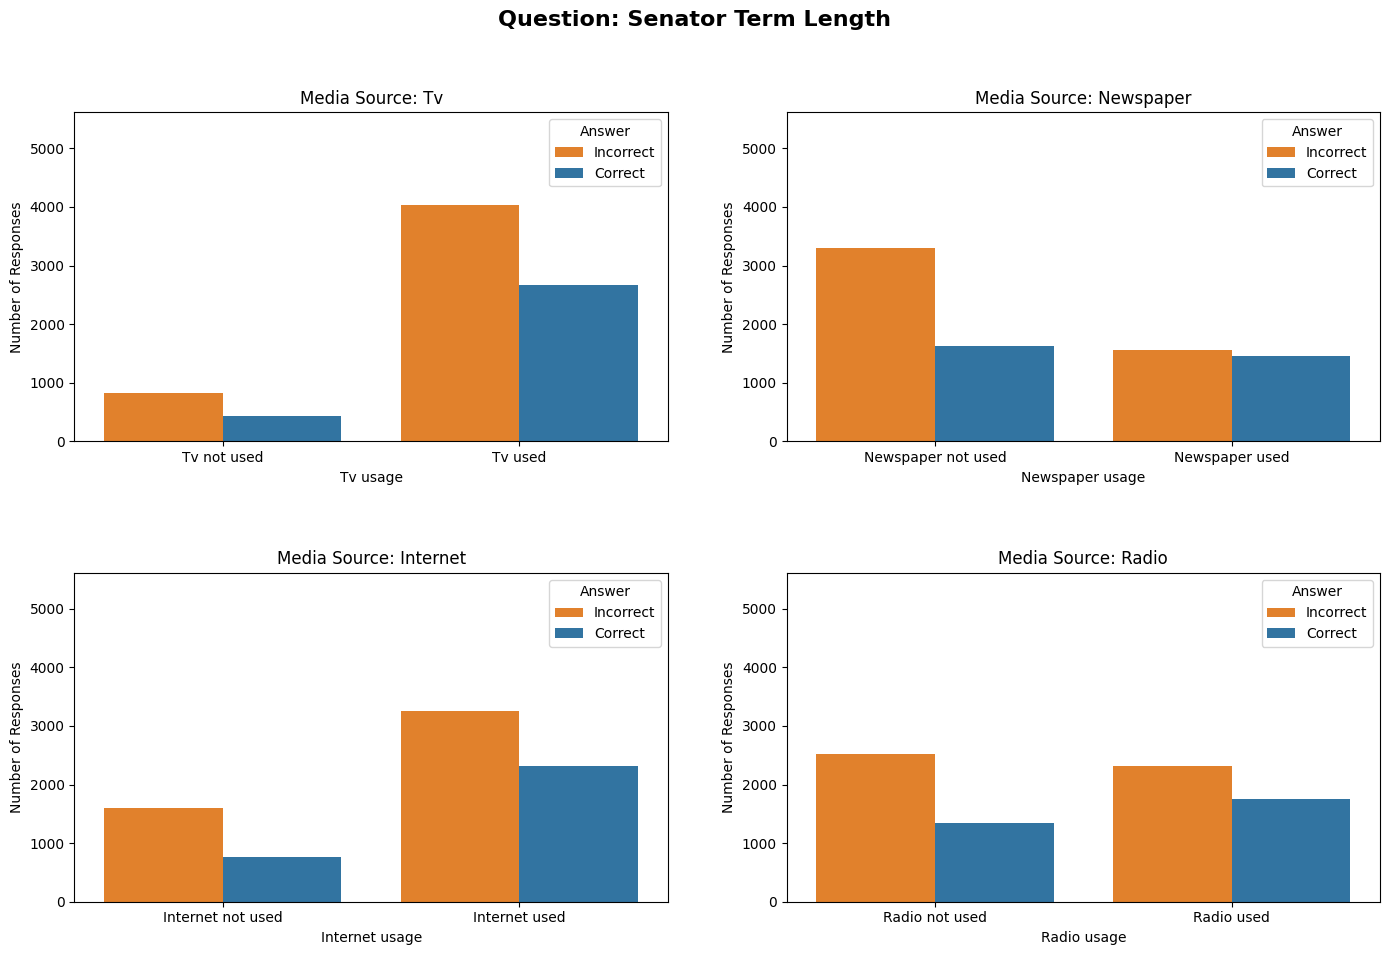

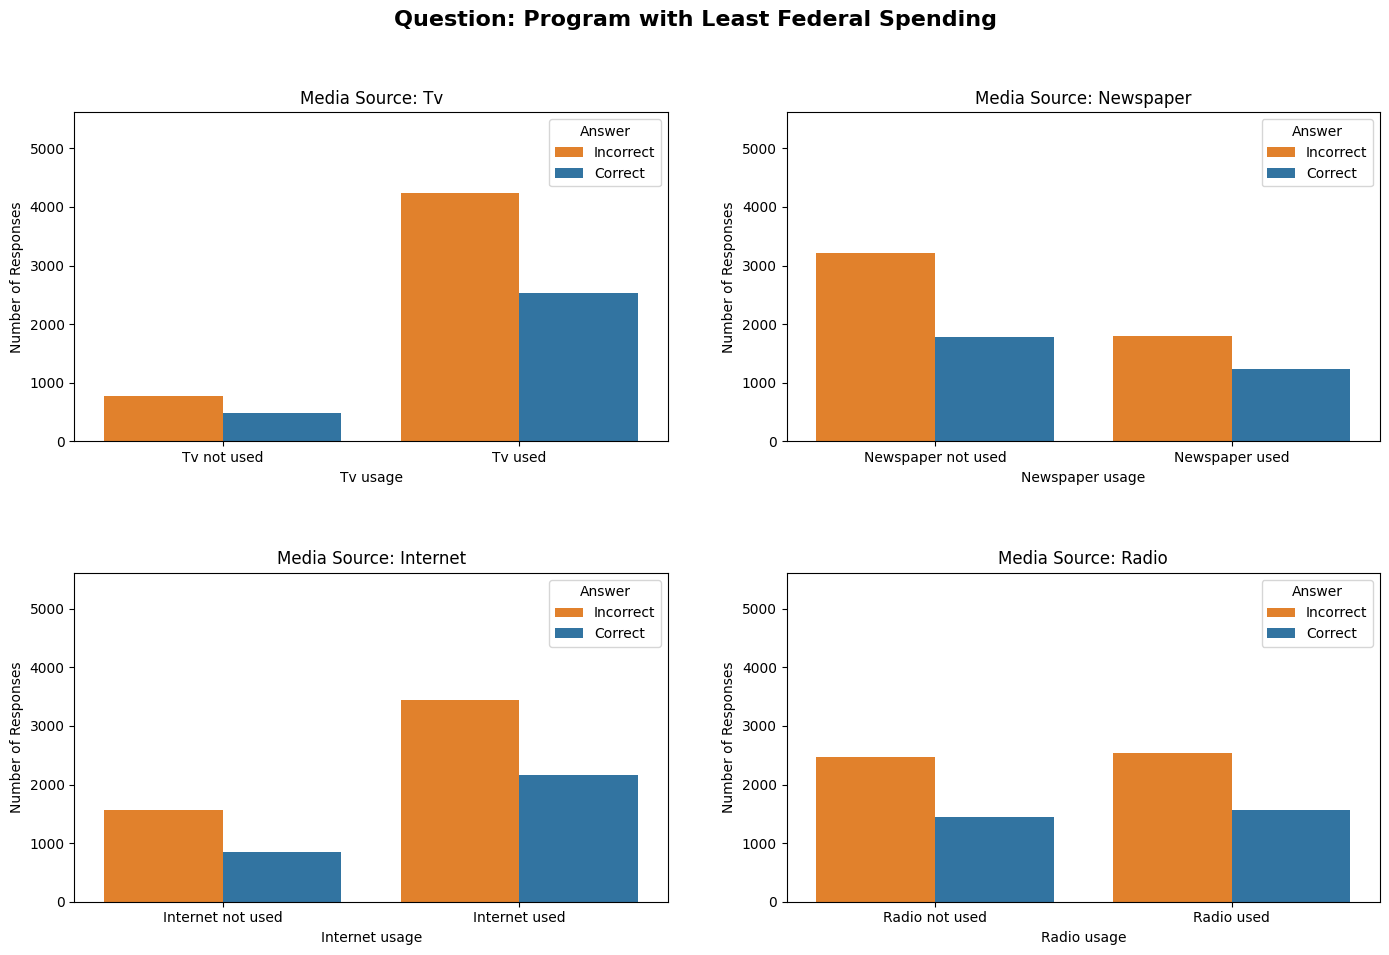

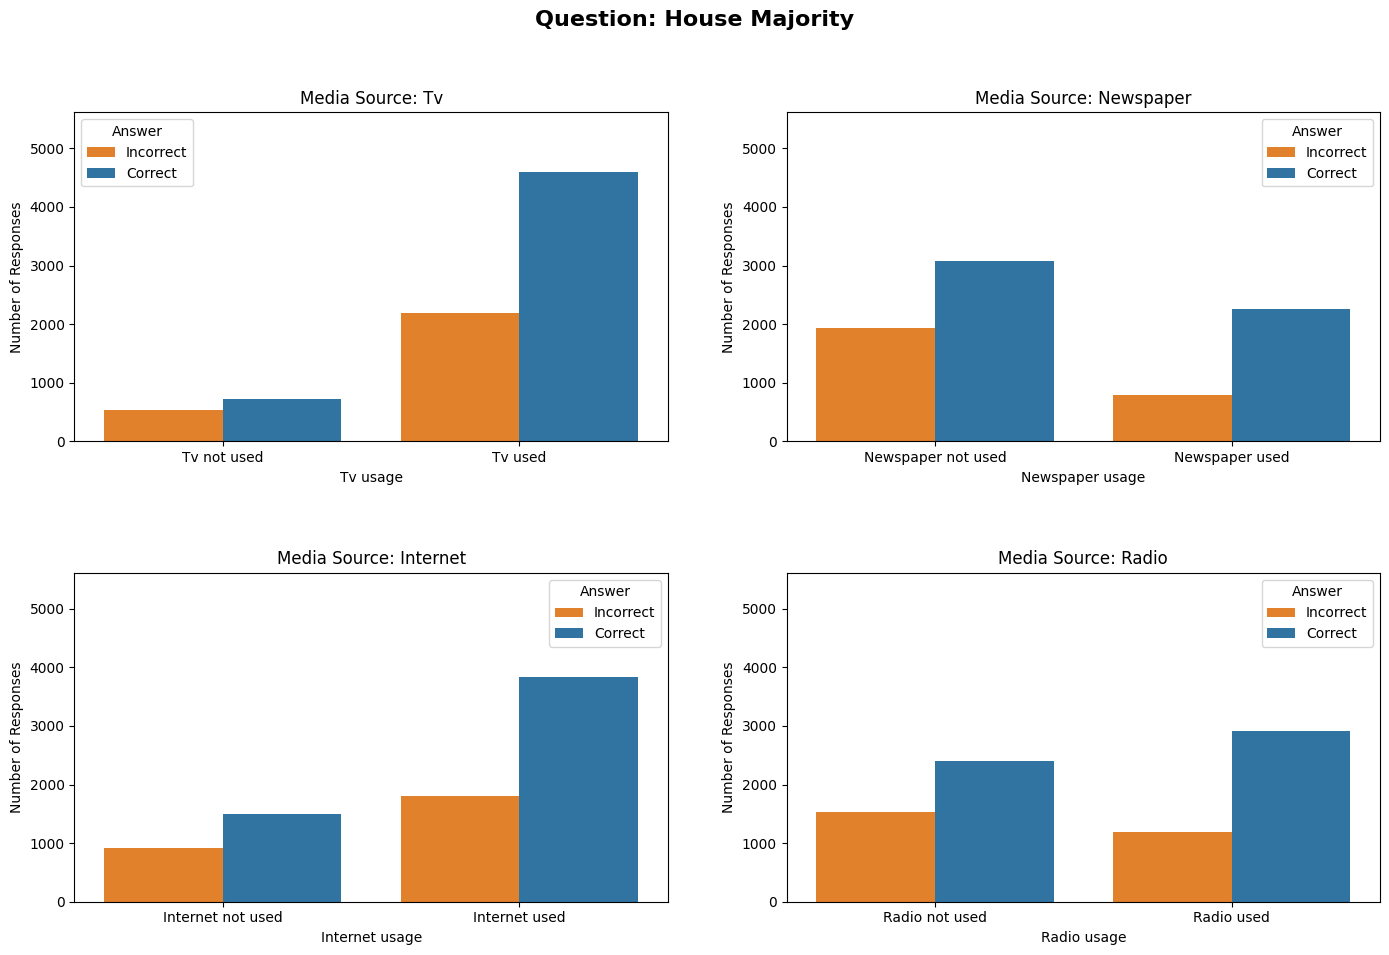

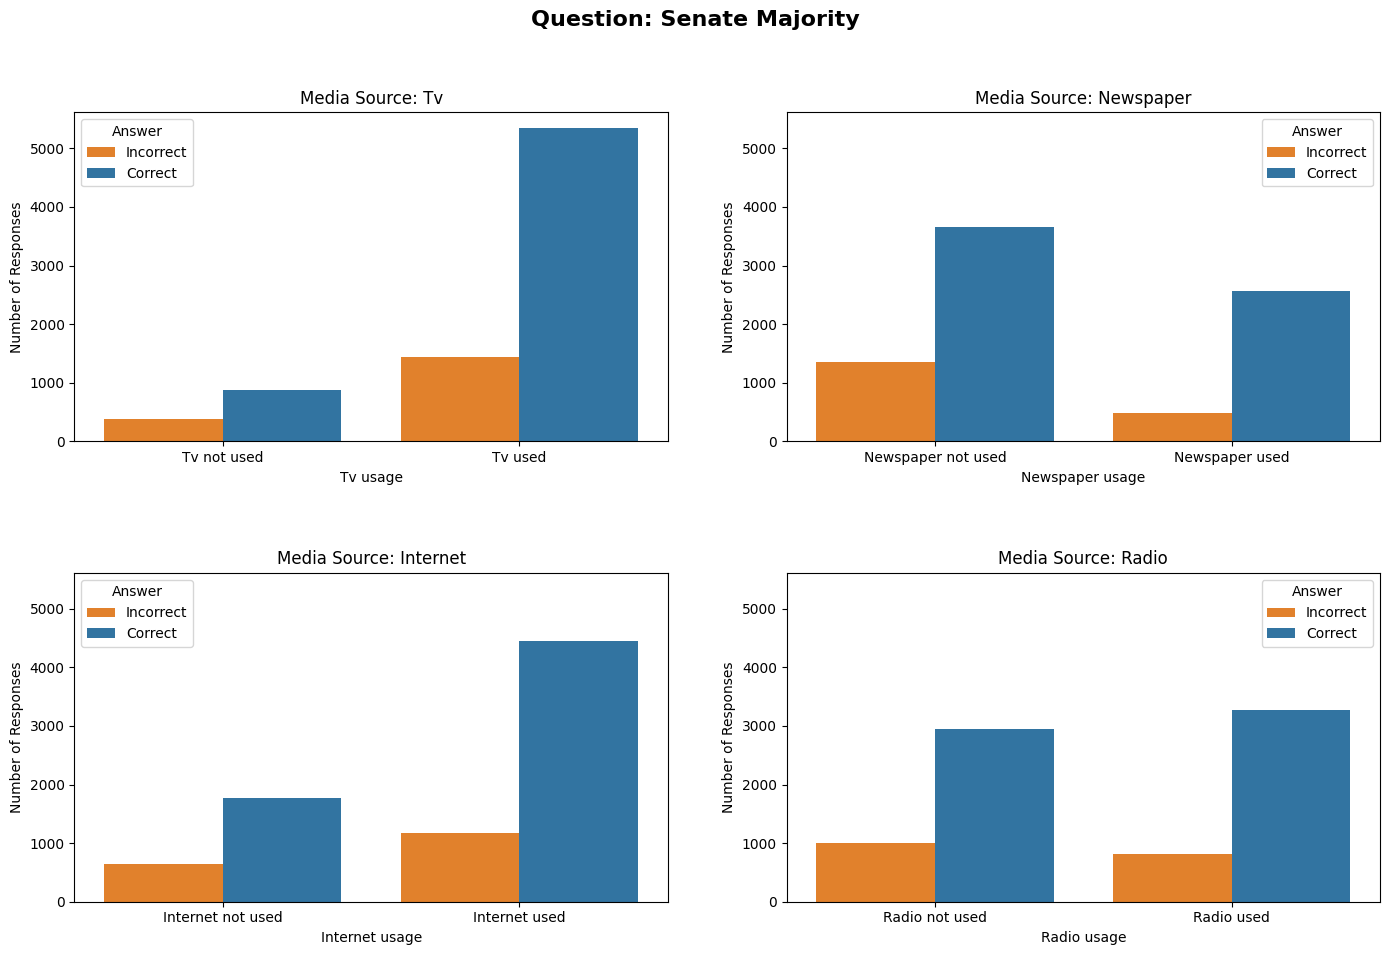

In [13]:
# init list of titles
titles = ["Senator Term Length", "Program with Least Federal Spending", "House Majority", "Senate Majority"]
t = -1

# find the highest y val so all the scaling is the same
ymax = 0
for fact in facts:
    for media in media_sources:
        current_max = model_df_recoded.groupby([media, fact])["weight_full_pre"].sum().max()
        if current_max > ymax:
            ymax = current_max
ymax *= 1.05


for fact in facts:
    t += 1
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Question: {titles[t]}', fontsize=16, fontweight='bold')
    axes_flat = axes.flatten()
    
    for i, media in enumerate(media_sources):
        media_title = media.split("_")[0].title()
        plot_data = (
            model_df_recoded.groupby([media, fact])['weight_full_pre']
            .sum()
            .reset_index()
        )
        plot_data.columns = [media, fact, 'Weighted Sum']
        
        # Charts:
            # x-axis: Was that media used?
            # y-axis: Number of respondents
            # hue: did they get the question right?
        sns.barplot(
            data=plot_data, 
            x=media, 
            y='Weighted Sum', 
            hue=fact, 
            ax=axes_flat[i],
            palette=("tab:orange", "tab:blue"),
        )
        

        # Formatting
        axes_flat[i].set_ylim(0, ymax)

        axes_flat[i].set_title(f"Media Source: {media_title}", fontsize=12)

        axes_flat[i].set_xlabel(f"{media_title} usage")
        axes_flat[i].set_xticks([0, 1])
        axes_flat[i].set_xticklabels([f"{media_title} not used", f"{media_title} used"])

        axes_flat[i].set_ylabel("Number of Responses")
        

        # Legend
        handles, labels = axes_flat[i].get_legend_handles_labels()
        axes_flat[i].legend(handles, ['Incorrect', 'Correct'], title="Answer")


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    plt.show()

---

# Analysis / Interpretation of Results

To begin with, the first two questions abuot senator term length and federal spending were seemingly harder for these participants. There were far more incorrect than correct answers for these questions. The second two questions about the house and senate majorities were seemingly more widely known information. This interpretation might help explain the huge number of incorrect answers observed in the former two questions vs the latter two questions. 


Let's take a look at a couple of the most interesting cases for each media type and see what we can find out.
<br><br>

## <b>Newspaper</b>
The question vs Newspaper tests all had huge Chi squared test statistics and tiny p-values (as shown above in the testing section). This means that it's extremely unlikely that the differences observed between the group who read the newspaper and the group that doesn't are due to chance. Also taking into account the weighted sample, this seems to be pretty strong evidence that any difference observed really is significant. See all the values below.

I'm focusing on two questions here. For the senator term length question, it's clear to see how the "used" group has a much smaller distance between the number of incorrect and correct answers than the "not used" group. From a difference of 1662.919 to 102.907. Since there were more incorrect than correct answers, seeing that distance decrease indicates that people who read the newspaper generally answer this question correctly more often than those who don't read read the newspaper. This is also visible in the comparison data, pulled from the code above in the descriptive section. Additionally, the chi2 test statistic is huge (180.497...), and the p-value is tiny (< 0.001). All of that is shown in the code block below.

The other interesting results are in the senate majority question. Although the absolute difference isn't very large, the proportion change between groups is pretty similar to the senator term questions. There's a 0.26/0.73 split for the "not used" group, and a 0.15/0.84 split for the "used" group. The proportion of correct answers increased by about 0.11 between groups, as compared to about a 0.15 increase for the senator term question. So we can see that even for the "easier" or more widely-known questions where more correct answers are given, reading the newspaper still has a positive impact on participants' political knowledge.

In [14]:
print(f"Newspaper: Chi2 Test Info")
display(f"Senator Term: {chi2_tables["senator_term-vs-newspaper_used"]}")
display(f"Least Fed Spending: {chi2_tables["least_fed_spending-vs-newspaper_used"]}")
display(f"House Majority: {chi2_tables["house_majority-vs-newspaper_used"]}")
display(f"Senate Majority: {chi2_tables["senate_majority-vs-newspaper_used"]}")

print(f"\n\nSenator Term Q")
display(comparison_tables["senator_term-vs-newspaper_used"])
display(chi2_tables["senator_term-vs-newspaper_used"])

print(f"\n\nSenate Majority Q")
display(comparison_tables["senate_majority-vs-newspaper_used"])
display(chi2_tables["senate_majority-vs-newspaper_used"])
print(f"\n\n\n\n\n")

Newspaper: Chi2 Test Info


"Senator Term: ('Chi2 Test Statistic: 180.4978568295369', 'p-value: 0.000000')"

"Least Fed Spending: ('Chi2 Test Statistic: 21.975004902643047', 'p-value: 0.000003')"

"House Majority: ('Chi2 Test Statistic: 141.89056075970143', 'p-value: 0.000000')"

"Senate Majority: ('Chi2 Test Statistic: 136.99851625778408', 'p-value: 0.000000')"

...

senator_term,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
newspaper_used,,,,,,
0.0,3293.586799,1630.667052,1662.919747,4924.253852,0.668850,0.331150
1.0,1557.279022,1454.371300,102.907723,3011.650322,0.517085,0.482915


('Chi2 Test Statistic: 180.4978568295369', 'p-value: 0.000000')



Senate Majority Q


senate_majority,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
newspaper_used,,,,,,
0.0,1344.509844,3652.150100,-2307.640256,4996.659944,0.269082,0.730918
1.0,474.562938,2564.723689,-2090.160751,3039.286627,0.156143,0.843857


('Chi2 Test Statistic: 136.99851625778408', 'p-value: 0.000000')

## <b>TV</b>
Newspaper saw the largest test statistics and tiniest p-values for every test, but what about the other media types?

The house and senate majority questions are where the TV media type shone in these tests, with statistics of 44.835 and 56.159 respectively (both had p-values of < 0.001 as well), as compared to the first two tests with 13.549 and 1.073 statistics. Again, a large test statistic and small p-value means that the difference being observed is very unlikely to be due to random chance. 

This makes intuitive sense -- people who watch TV would do well with general questions like the split in the house or senate, but might not do as well with more in-depth questions like what program the federal government spends the least on. Look below at the three question tables, with the two house/senate questions having a correct answer proportion difference of about 0.10 each whereas the least federal spending question actually has a negative, negligible difference of about 0.01.

In [15]:
print(f"TV: Chi2 Test Info")
display(f"Senator Term: {chi2_tables["senator_term-vs-tv_used"]}")
display(f"Least Fed Spending: {chi2_tables["least_fed_spending-vs-tv_used"]}")
display(f"House Majority: {chi2_tables["house_majority-vs-tv_used"]}")
display(f"Senate Majority: {chi2_tables["senate_majority-vs-tv_used"]}")

print(f"\n\nHouse Majority Q")
display(comparison_tables["house_majority-vs-tv_used"])
display(chi2_tables["house_majority-vs-tv_used"])

print(f"\n\nSenate Majority Q")
display(comparison_tables["senate_majority-vs-tv_used"])
display(chi2_tables["senate_majority-vs-tv_used"])

print(f"\n\nLeast Federal Spending Q")
display(comparison_tables["least_fed_spending-vs-tv_used"])
display(chi2_tables["least_fed_spending-vs-tv_used"])
print(f"\n\n\n\n\n")

TV: Chi2 Test Info


"Senator Term: ('Chi2 Test Statistic: 13.549031790488595', 'p-value: 0.000232')"

"Least Fed Spending: ('Chi2 Test Statistic: 1.073947224845533', 'p-value: 0.300056')"

"House Majority: ('Chi2 Test Statistic: 44.835119073920005', 'p-value: 0.000000')"

"Senate Majority: ('Chi2 Test Statistic: 56.1599752041327', 'p-value: 0.000000')"

...

senate_majority,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
tv_used,,,,,,
0.0,387.095361,869.636671,-482.541310,1256.732032,0.308017,0.691983
1.0,1431.977421,5347.237118,-3915.259697,6779.214540,0.211231,0.788769


('Chi2 Test Statistic: 56.1599752041327', 'p-value: 0.000000')



Least Federal Spending Q


least_fed_spending,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
tv_used,,,,,,
0.0,765.509977,487.130959,278.379018,1252.640936,0.611117,0.388883
1.0,4244.719070,2524.899550,1719.819519,6769.618620,0.627025,0.372975


('Chi2 Test Statistic: 1.073947224845533', 'p-value: 0.300056')

## <b>Radio</b>
Radio follows a pretty similar pattern to TV. This makes intuitive sense. Radio and TV are both commonly consumed passively in the U.S.; while driving, cooking dinner, or generally doing something else and not giving full attention to the content more often than not.

In the data, we see roughly 500 more correct answers for the house majority question with a similar total number of responses in each group (around 4000). A similar pattern can be seen for the senator term length question, with around 400 more correct answers for around 4000 respondents in both groups.

Again, we see the two "easier" questions with higher statistics / lower p-values and the "harder" questions with the opposite, but with one exception this time. The first question about senator term length has a pretty large statistic of 57.485 and a tiny p-value < 0.001. This large test statistic and small p-value means that the difference here is very unlikely to be due to random chance. 

Why is this the case? I'm honestly not sure. My best guess is that radio consumers have to actively seek out radio stations much more than tv viewers have to actively seek out news channels. TV news channels are on in public spaces, whereas political radio shows might be more niche, not played in as many public spaces, or might be harder to find where radio is commonly used. Therefore, that more dedicated user base might be more politically involved and knowledgeable?

However, we see that this type of passive consumer still doesn't perform well on what seems to be the "hardest" question here, the least federal spending question. This is distinct from the more active forms of media consumption like reading the newspaper and the internet, which I'll get into in a second...

See some statistics:

In [16]:
print(f"Radio: Chi2 Test Info")
display(f"Senator Term: {chi2_tables["senator_term-vs-radio_used"]}")
display(f"Least Fed Spending: {chi2_tables["least_fed_spending-vs-radio_used"]}")
display(f"House Majority: {chi2_tables["house_majority-vs-radio_used"]}")
display(f"Senate Majority: {chi2_tables["senate_majority-vs-radio_used"]}")

print(f"\n\nHouse Majority Q")
display(comparison_tables["house_majority-vs-radio_used"])
display(chi2_tables["house_majority-vs-radio_used"])

print(f"\n\nSenator Term Q")
display(comparison_tables["senator_term-vs-radio_used"])
display(chi2_tables["senator_term-vs-radio_used"])

print(f"\n\nLeast Federal Spending Q")
display(comparison_tables["least_fed_spending-vs-radio_used"])
display(chi2_tables["least_fed_spending-vs-radio_used"])
print(f"\n\n\n\n\n")

Radio: Chi2 Test Info


"Senator Term: ('Chi2 Test Statistic: 57.48553603216443', 'p-value: 0.000000')"

"Least Fed Spending: ('Chi2 Test Statistic: 1.4919101352330075', 'p-value: 0.221920')"

"House Majority: ('Chi2 Test Statistic: 92.24942009309304', 'p-value: 0.000000')"

"Senate Majority: ('Chi2 Test Statistic: 31.230028793734338', 'p-value: 0.000000')"

...

senator_term,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
radio_used,,,,,,
0.0,2528.308264,1337.896366,1190.411898,3866.204630,0.653951,0.346049
1.0,2322.557558,1747.141986,575.415571,4069.699544,0.570695,0.429305


('Chi2 Test Statistic: 57.48553603216443', 'p-value: 0.000000')



Least Federal Spending Q


least_fed_spending,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
radio_used,,,,,,
0.0,2477.279194,1446.078705,1031.200489,3923.357898,0.631418,0.368582
1.0,2532.949853,1565.951804,966.998049,4098.901657,0.617958,0.382042


('Chi2 Test Statistic: 1.4919101352330075', 'p-value: 0.221920')

## <b>Internet</b>
Like radio use roughly follows the patterns of tv use, internet use roughly follows the patterns of newspaper use. I already hinted at this, but I think this is due to the active vs. passive nature of these media sources. You have to make an effort to read the newspaper or read an internet site, whereas you don't have to use nearly as much effort to listen to the tv or radio in the background.

For this media source, we see medium to relatively large test statistics across all the questions, even the "harder ones", and some very small p-values. Those indicate that the difference we're observing is unlikely to be due to random chance. The stats for the first two questions are shown below. For instance, we see a test statistic of 61.942 and a p-value of < 0.001 for the senator term question. The difference in proportion between correct answers for this question between groups is around 0.09, decently close to the ~0.15 difference observed for the same question with newspaper use. The more interesting one is for internet use on the least federal spending question, where the proportion difference for correct answers is around 0.04 compared to the difference of around 0.05 for newspaper use.

See the stats below:

In [17]:
print(f"Internet: Chi2 Test Info")
display(f"Senator Term: {chi2_tables["senator_term-vs-internet_used"]}")
display(f"Least Fed Spending: {chi2_tables["least_fed_spending-vs-internet_used"]}")
display(f"House Majority: {chi2_tables["house_majority-vs-internet_used"]}")
display(f"Senate Majority: {chi2_tables["senate_majority-vs-internet_used"]}")

print(f"\n\nSenator Term Q")
display(comparison_tables["senator_term-vs-internet_used"])
display(chi2_tables["senator_term-vs-internet_used"])

print(f"================ Senator Term Q (FOR NEWSPAPER USE)================")
display(comparison_tables["senator_term-vs-newspaper_used"])
display(chi2_tables["senator_term-vs-newspaper_used"])

print(f"\n\nLeast Federal Spending Q")
display(comparison_tables["least_fed_spending-vs-internet_used"])
display(chi2_tables["least_fed_spending-vs-internet_used"])
print(f"\n\n\n\n\n")

Internet: Chi2 Test Info


"Senator Term: ('Chi2 Test Statistic: 61.94230348232778', 'p-value: 0.000000')"

"Least Fed Spending: ('Chi2 Test Statistic: 9.669528047702158', 'p-value: 0.001873')"

"House Majority: ('Chi2 Test Statistic: 29.31301872612456', 'p-value: 0.000000')"

"Senate Majority: ('Chi2 Test Statistic: 31.116717932622247', 'p-value: 0.000000')"

...

senator_term,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
newspaper_used,,,,,,
0.0,3293.586799,1630.667052,1662.919747,4924.253852,0.668850,0.331150
1.0,1557.279022,1454.371300,102.907723,3011.650322,0.517085,0.482915


('Chi2 Test Statistic: 180.4978568295369', 'p-value: 0.000000')



Least Federal Spending Q


least_fed_spending,Incorrect,Correct,<<< Difference,Total Answers,Prop Incorrect,Prop Correct
internet_used,,,,,,
0.0,1567.503130,842.545036,724.958094,2410.048166,0.650403,0.349597
1.0,3442.725917,2169.485473,1273.240444,5612.211390,0.613435,0.386565


('Chi2 Test Statistic: 9.669528047702158', 'p-value: 0.001873')

## <b>Conclusion</b>

In conclusion, through this research, I've identified that different types of media have different patterns of effects on these ANES survey participants' politcal knowledge.I identified two key categories of media present in this study: "passive" and "active" media, and hypothesized a couple unique things about each group.

First, I believe that passive media like radio and TV is usually played in the background while other tasks are being performed. While I believe this media helps people learn more general information about politics, due to the distracted nature of a large proportion of their consumption, I don't think it gives an in-depth picture of the political landscape usually for these consumers, and therefore only leads to notable increases in political knowledge being observed on more "general" or "easier" questions like those about who's winning the race in the house or senate. I noticed multiple distinct statistical patterns in the Chi2 tests I ran, the descriptive statistics I performed on the data, and the visualizations I created. 

Alternatively, I believe that active media like newspaper and the internet takes more energy and effort to consume. I noticed patterns in my statistical testing, descriptive statistics, and visualizations that indicated that this active consumption lead to a deeper level of political knowledge. Also, since the p-values were generally smaller and test statistics were generally larger, the differences between the newspaper/internet "used" and "not used" groups observed are extremely unlikely to be observed by random chance. The data indicates that there is a noticeable difference in participants' political knowledge when they actively use these media sources vs passively using the others.

---

# Discussion of Survey Design
- How might question wording affect your findings?
- What response biases might be present in this data?
- How do ANES sampling and weighting procedures affect interpretation?
- Compare self-report survey data to behavioral/observational data for your topic

These are the questions I looked at:
- From which of the following sources have you heard anything about the presidential campaign? (Mark all that apply)
- For how many years is a United States Senator elected – that is, how many years are there in one full term of office for a U.S. Senator?<br>
- On which of the following does the U.S. federal government currently spend the least?   //   1. Foreign aid 2. Medicare 3. National defense 4. Social Security<br>
- Do you happen to know which party currently has the most members in the U.S. House of Representatives in Washington?   //   1. Democrats 2. Republicans<br>
- Do you happen to know which party currently has the most members in the U.S. Senate?   //   1. Democrats 2. Republicans
<br><br>

1. In terms of how question woring might affect these findings, I have two things I want to talk about.
    - The first is that "heard anything about" is very vauge, and that users might over-report here for media sources they don't actually use that much. It's also implied to be a time scale as long as the election, so pretty extensive. People could also forget what they actually used or whaere they heard things from because of that. This might skew the results in some way. It's hard to say exactly.
    - The second is that "foreign aid" is sort of a trap answer, as we talk a lot in our news about foreign aid. I think that this might lead to people overestimating how much we actually spend on foreign aid, and isn't the fairest answer choices. The other choices given are things that people generally think of as the government spending a lot of money on, too. Because of this, I think it's reasonable to say that some participants might have not really known or had the appropriate background to answer the question and just guessed. While this question does measure political knowledge, the results also might be a little skewed because of that.
2. Social Desirability Bias might be present here. People might want to seem like good citizens and report more news consumption than what they really did. The Primacy effect is almost always a concern with long surveys like the ANES, especially on questions like some of the multi-select questions like the ones I sampled. Users who were tired of the survey by that point might have just selected the first option that worked, not fully read the question, and moved on, not realizing it was a multi-select because they just want to get the survey over with.
3. ANES sampling and weighting procedures make this data a lot more viable to use in research like this. Since the ANES can't have a perfectly random sample, they use weights based on large census data--the best they can get--to help make the data more generalizable and representative of the real population. Because of these weights, we're able to conclude more about larger, more general groups of people than we would be without them, especially since on a survey based around politics, different types of people might answer questions very differently from one another
4. Self-report survey data tells you about what people think they do, or potentially what they want to be perceived as doing. Self-reported data doesn't always match behavioral data. While surveys can reveal invisible beliefs and perceptions, as well as provide with a sample that behavioral methods realistically almost never could, they aren't perfect, and the errors that come along with them like, in this case, question wording effects, social desirability bias, and the primacy effect may skew the results in some ways that we don't expect as researchers.

---

# AI Appendix

- I used AI as a starting point for parts of this research. The main one was that I ideated on some visualization ideas using AI. I ended up going a different direction, but it was helpful for getting started and having something to bring to OH and class.
    - I had no idea how to put multiple plots into one figure and iterate through dynamically. Once I used AI, I was able to understand how it works and then actually edit it to fit my research question and analytical needs.
- There is a lot of matplotlib/seaborn syntax I don't know. I used AI as a "faster google" here to figure out syntax and how it would directly apply to my code.
- I used AI to figure out how to create crosstabs and groupbys to make the nice looking tables I used a ton throughout my descriptive statistics section
- Much of the code for the statistical testing was initially created using AI, but I edited it a ton to fit my needs. Again, I used it as a starting point and then went from there, checking things like syntax, fixing errors, etc.

I used AI plenty on this assignment as a tool, but the meat of the assignment came from me sitting down and doing it, with AI in the background available when I needed it.